# Gene-wise 3D spatial negative-binomial simulation using all slices

This notebook fits the gene-expression model jointly to all available slices rather than restricting the analysis to slice `A6`.

For cell $i$ and gene $g$, the model is

$$
Y_{ig}\mid\mu_{ig},\alpha_g
\sim
\operatorname{NB2}(\mu_{ig},\alpha_g),
$$

with

$$
\log\mu_{ig}
=
\log L_i^{+}
+
\boldsymbol{X}_i^\top\boldsymbol{\beta}_g
+
\boldsymbol{B}(x_i,y_i,z_i)^\top\boldsymbol{\gamma}_g.
$$

The biological design matrix contains an intercept, predicted cell-type indicators, and predicted domain indicators. The spatial effect is represented by 3D radial basis functions constructed from $(x_i,y_i,z_i)$. The design matrix, offset, and spatial basis are constructed once and reused for all genes.

The notebook records every failed gene rather than silently treating it as a successful fit. Failed genes are filled with zeros only in the simulated expression matrix, and their failure reasons are saved separately in `gene_fit_status_all_slices.csv`.


In [1]:
import os
import gc
import re
import time
import warnings

import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import statsmodels.api as sm
import matplotlib.pyplot as plt

from scipy import sparse
from scipy.stats import nbinom, rankdata
from sklearn.cluster import MiniBatchKMeans
from sklearn.neighbors import NearestNeighbors

OUTPUT_DIR = "./gene_expression_all_slices"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Update this path only if the input file is stored elsewhere.
DATA_PATH = "../adata_backup_with_pred_region_celltype.h5ad"

RANDOM_SEED = 123
N_SPATIAL_BASIS = 30
MIN_NONZERO = 10
K_MORAN = 15


In [2]:
# ============================================================
# Design matrix and 3D spatial basis
# ============================================================

def build_design_matrix(meta):
    """Construct intercept, cell-type dummies, and domain dummies."""
    ct = pd.get_dummies(
        meta["cell_type"],
        prefix="celltype",
        drop_first=True,
        dtype=float
    )
    dom = pd.get_dummies(
        meta["domain"],
        prefix="domain",
        drop_first=True,
        dtype=float
    )

    intercept = pd.Series(
        1.0,
        index=meta.index,
        name="Intercept"
    )

    X = pd.concat([intercept, ct, dom], axis=1)
    return X.astype(float)


def make_spatial_basis(coords, n_basis=30, random_state=123):
    """Construct a 3D RBF basis from standardized coordinates."""
    coords = np.asarray(coords, dtype=np.float64)

    if coords.ndim != 2:
        raise ValueError("coords must be a two-dimensional array.")

    if not np.isfinite(coords).all():
        raise ValueError("Spatial coordinates contain NaN or Inf.")

    coord_mean = coords.mean(axis=0)
    coord_sd = coords.std(axis=0)
    coords_std = (coords - coord_mean) / (coord_sd + 1e-8)

    n = coords_std.shape[0]
    n_basis = min(int(n_basis), n)

    if n_basis < n:
        km = MiniBatchKMeans(
            n_clusters=n_basis,
            random_state=random_state,
            batch_size=min(4096, n),
            n_init="auto"
        )
        centers = km.fit(coords_std).cluster_centers_
    else:
        centers = coords_std.copy()

    d2 = np.sum(
        (coords_std[:, None, :] - centers[None, :, :]) ** 2,
        axis=2
    )

    center_d2 = np.sum(
        (centers[:, None, :] - centers[None, :, :]) ** 2,
        axis=2
    )
    center_dist = np.sqrt(center_d2)
    positive_dist = center_dist[center_dist > 0]

    bandwidth = (
        np.median(positive_dist)
        if positive_dist.size > 0
        else 1.0
    )
    bandwidth = max(float(bandwidth), 1e-6)

    basis = np.exp(-0.5 * d2 / bandwidth**2)

    B = pd.DataFrame(
        basis,
        columns=[
            f"spatial_rbf_{k + 1}"
            for k in range(n_basis)
        ]
    )

    basis_info = {
        "coord_mean": coord_mean,
        "coord_sd": coord_sd,
        "centers": centers,
        "bandwidth": bandwidth
    }

    return B.astype(float), coords_std, basis_info


def prepare_shared_model_components(meta, n_spatial_basis=30):
    """
    Construct the biological design matrix, 3D RBF basis, and offset once.
    These quantities are shared by every gene.
    """
    coords_raw = meta[["x", "y", "z"]].to_numpy(dtype=np.float64)

    B, coords_std, basis_info = make_spatial_basis(
        coords_raw,
        n_basis=n_spatial_basis,
        random_state=RANDOM_SEED
    )

    X_base = build_design_matrix(meta).reset_index(drop=True)
    X = pd.concat(
        [X_base, B.reset_index(drop=True)],
        axis=1
    )

    X_np = X.to_numpy(dtype=np.float64)

    library_size = np.maximum(
        meta["library_size"].to_numpy(dtype=np.float64),
        1e-8
    )
    offset = np.log(library_size)

    if not np.isfinite(X_np).all():
        raise ValueError("The shared design matrix contains NaN or Inf.")

    if not np.isfinite(offset).all():
        raise ValueError("The library-size offset contains NaN or Inf.")

    return {
        "X": X,
        "X_np": X_np,
        "offset": offset,
        "coords_std": coords_std,
        "basis_info": basis_info
    }


# ============================================================
# Gene-wise Poisson moment-alpha and NB2 fitting
# ============================================================

def fit_one_gene_precomputed(
    y,
    X_np,
    offset,
    min_nonzero=10,
    poisson_maxiter=50,
    nb_maxiter=100
):
    """
    First fit a Poisson GLM to obtain the moment-based estimate of alpha,
    then fit the NB2 GLM using the same shared design matrix and offset.
    """
    y = np.asarray(y, dtype=np.float64).copy()

    # Force integer-valued counts
    y = np.round(y)

    # Prevent negative values
    y[y < 0] = 0

    nonzero = int(np.count_nonzero(y))
    y_var = float(np.var(y))
    y_sum = float(np.sum(y))
    y_max = float(np.max(y)) if y.size else np.nan

    if nonzero < min_nonzero or y_var < 1e-12:
        raise ValueError(
            "Gene too sparse or constant for spatial NB-GLM fitting: "
            f"nonzero={nonzero}, required={min_nonzero}, var={y_var}"
        )

    captured_warnings = []

    with warnings.catch_warnings(record=True) as warning_records:
        warnings.simplefilter("always")

        poisson_fit = sm.GLM(
            y,
            X_np,
            family=sm.families.Poisson(),
            offset=offset
        ).fit(
            maxiter=poisson_maxiter,
            disp=0
        )

        mu0 = np.asarray(
            poisson_fit.fittedvalues,
            dtype=np.float64
        )

        if not np.isfinite(mu0).all():
            raise FloatingPointError(
                "The Poisson GLM produced non-finite fitted means."
            )

        mu0 = np.maximum(mu0, 1e-8)

        alpha_denominator = float(np.sum(mu0**2))
        if (
            not np.isfinite(alpha_denominator)
            or alpha_denominator <= 0
        ):
            raise FloatingPointError(
                "The moment-alpha denominator is invalid."
            )

        alpha_raw = float(
            np.sum((y - mu0) ** 2 - mu0)
            / alpha_denominator
        )

        if not np.isfinite(alpha_raw):
            raise FloatingPointError(
                "The moment-based alpha estimate is non-finite."
            )

        alpha = float(
            np.clip(alpha_raw, 1e-8, 100.0)
        )

        nb_fit = sm.GLM(
            y,
            X_np,
            family=sm.families.NegativeBinomial(
                alpha=alpha
            ),
            offset=offset
        ).fit(
            maxiter=nb_maxiter,
            disp=0
        )

        beta = np.asarray(
            nb_fit.params,
            dtype=np.float64
        )

        if not np.isfinite(beta).all():
            raise FloatingPointError(
                "The NB2 GLM produced non-finite coefficients."
            )

        for warning_record in warning_records:
            captured_warnings.append(
                str(warning_record.message)
            )

    return {
        "beta": beta,
        "alpha": alpha,
        "alpha_raw": alpha_raw,
        "poisson_converged": bool(
            getattr(poisson_fit, "converged", True)
        ),
        "nb_converged": bool(
            getattr(nb_fit, "converged", True)
        ),
        "warnings": " | ".join(
            dict.fromkeys(captured_warnings)
        ),
        "nonzero": nonzero,
        "variance": y_var,
        "sum": y_sum,
        "max": y_max
    }


def simulate_one_gene_precomputed(
    fit_result,
    X_np,
    offset,
    seed
):
    """Simulate one gene from the fitted NB2 model."""
    rng = np.random.default_rng(seed)

    beta = fit_result["beta"]
    alpha = float(fit_result["alpha"])

    eta = X_np @ beta + offset
    eta = np.clip(eta, -20, 20)
    mu = np.exp(eta)

    r = 1.0 / max(alpha, 1e-8)
    p = r / (r + mu)
    p = np.clip(p, 1e-12, 1.0 - 1e-12)

    y_sim = nbinom(
        n=r,
        p=p
    ).rvs(
        random_state=rng
    )

    return np.asarray(y_sim, dtype=np.int32)


def extract_count_matrix(adata_obj):
    """Return the observed counts as a cells-by-genes int32 matrix."""
    if "counts" not in adata_obj.layers:
        raise KeyError("adata.layers['counts'] is missing.")

    counts = adata_obj.layers["counts"]

    if sparse.issparse(counts):
        counts = counts.toarray()
    else:
        counts = np.asarray(counts)

    counts = np.rint(counts).astype(np.int32)
    counts[counts < 0] = 0

    return counts


In [3]:
# ============================================================
# Load data and use all slices
# ============================================================

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Input AnnData file not found: {DATA_PATH}\n"
        "Place adata_backup_with_pred_region_celltype.h5ad at this path "
        "or update DATA_PATH."
    )

adata = sc.read(DATA_PATH)

required_obs = [
    "x",
    "y",
    "z",
    "batch",
    "size",
    "pred_region",
    "pred_celltype"
]

missing_obs = [
    key for key in required_obs
    if key not in adata.obs.columns
]

if missing_obs:
    raise KeyError(
        f"Missing required adata.obs columns: {missing_obs}"
    )

if "counts" not in adata.layers:
    raise KeyError("adata.layers['counts'] is required.")

# Use every cell from every slice
adata_all = adata.copy()

meta = pd.DataFrame({
    "x": adata_all.obs["x"].to_numpy(),
    "y": adata_all.obs["y"].to_numpy(),
    "z": adata_all.obs["z"].to_numpy(),
    "batch": adata_all.obs["batch"].astype(str).to_numpy(),
    "cell_type": adata_all.obs["pred_celltype"].astype(str).to_numpy(),
    "domain": adata_all.obs["pred_region"].astype(str).to_numpy(),
    "library_size": adata_all.obs["size"].to_numpy()
}, index=adata_all.obs_names)

print(adata_all)
print("\nNumber of cells:", adata_all.n_obs)
print("Number of genes:", adata_all.n_vars)
print("Number of slices:", meta["batch"].nunique())
print("\nCells per slice:")
print(meta["batch"].value_counts().sort_index())
print("\nUnique z values:")
print(np.sort(meta["z"].unique()))


AnnData object with n_obs × n_vars = 64373 × 155
    obs: 'Animal_ID', 'Animal_sex', 'Behavior', 'Bregma', 'Centroid_X', 'Centroid_Y', 'Cell_class', 'Neuron_cluster_ID', 'slices', 'Coord_X', 'Coord_Y', 'x', 'y', 'z', 'cell_type', 'batch', 'n_genes', 'size', 'STAIR', 'pred_region', 'pred_celltype'
    var: 'n_cells'
    uns: 'batch_colors', 'cell_type_colors', 'log1p', 'pred_celltype_names'
    obsm: 'STAIR', 'STAIR_clean', 'XYZ_rel_pca_global', 'latent', 'pred_celltype_proba', 'spatial', 'spatial_2d_raw', 'spatial_2d_raw_rotate', 'spatial_2d_μm', 'spatial_2d_μm_rotate', 'spatial_3d', 'spatial_3d_raw', 'spatial_3d_raw_rotate', 'spatial_3d_μm', 'spatial_3d_μm_rotate'
    layers: 'Denoise', 'counts', 'noise1', 'noise2', 'noise3', 'noise4'

Number of cells: 64373
Number of genes: 155
Number of slices: 12

Cells per slice:
batch
A0     4832
A1     4787
A10    5543
A11    5517
A2     5169
A3     5070
A4     5343
A5     5338
A6     5488
A7     5557
A8     5926
A9     5803
Name: count, dtype: 

In [4]:
# ============================================================
# Prepare shared 3D model components once
# ============================================================

shared = prepare_shared_model_components(
    meta,
    n_spatial_basis=N_SPATIAL_BASIS
)

X = shared["X"]
X_np = shared["X_np"]
offset = shared["offset"]
coords_std = shared["coords_std"]

print("Shared design matrix shape:", X_np.shape)
print("Number of biological columns:", X.shape[1] - N_SPATIAL_BASIS)
print("Number of 3D RBF columns:", N_SPATIAL_BASIS)
print("RBF bandwidth:", shared["basis_info"]["bandwidth"])
print("Reference encoding is determined by the dropped first category.")


Shared design matrix shape: (64373, 51)
Number of biological columns: 21
Number of 3D RBF columns: 30
RBF bandwidth: 2.2613564934291803
Reference encoding is determined by the dropped first category.


In [5]:
# ============================================================
# Fit and simulate all genes jointly across all slices
# ============================================================

Y_true = extract_count_matrix(adata_all)
gene_names = adata_all.var_names.astype(str).tolist()

sim_expr = np.zeros(
    (adata_all.n_obs, adata_all.n_vars),
    dtype=np.int32
)

fit_records = []
gene_fits = {}

start_time = time.time()

for j, gene in enumerate(gene_names):
    gene_start = time.time()

    y = Y_true[:, j]
    nonzero = int(np.count_nonzero(y))
    variance = float(np.var(y))

    print(
        f"[{j + 1:03d}/{len(gene_names):03d}] "
        f"{gene}: nonzero={nonzero}, var={variance:.6g}",
        flush=True
    )

    try:
        fit_result = fit_one_gene_precomputed(
            y=y,
            X_np=X_np,
            offset=offset,
            min_nonzero=MIN_NONZERO
        )

        y_sim = simulate_one_gene_precomputed(
            fit_result=fit_result,
            X_np=X_np,
            offset=offset,
            seed=RANDOM_SEED + j
        )

        sim_expr[:, j] = y_sim
        gene_fits[gene] = {
            "beta": np.asarray(
                fit_result["beta"],
                dtype=np.float64
            ),
            "alpha": float(fit_result["alpha"])
        }

        status = (
            "success"
            if (
                fit_result["poisson_converged"]
                and fit_result["nb_converged"]
            )
            else "nonconverged"
        )

        error_message = ""

        fit_records.append({
            "gene": gene,
            "status": status,
            "error": error_message,
            "nonzero": fit_result["nonzero"],
            "variance": fit_result["variance"],
            "observed_sum": fit_result["sum"],
            "observed_max": fit_result["max"],
            "alpha_raw": fit_result["alpha_raw"],
            "alpha": fit_result["alpha"],
            "poisson_converged": fit_result["poisson_converged"],
            "nb_converged": fit_result["nb_converged"],
            "warnings": fit_result["warnings"],
            "elapsed_seconds": time.time() - gene_start
        })

    except Exception as exc:
        # If fitting fails, fill the simulated counts with zeros
        sim_expr[:, j] = 0

        fit_records.append({
            "gene": gene,
            "status": "failed",
            "error": f"{type(exc).__name__}: {exc}",
            "nonzero": nonzero,
            "variance": variance,
            "observed_sum": float(np.sum(y)),
            "observed_max": float(np.max(y)) if y.size else np.nan,
            "alpha_raw": np.nan,
            "alpha": np.nan,
            "poisson_converged": False,
            "nb_converged": False,
            "warnings": "",
            "elapsed_seconds": time.time() - gene_start
        })

        print(
            f"    FAILED: {type(exc).__name__}: {exc}",
            flush=True
        )

    if (j + 1) % 10 == 0 or (j + 1) == len(gene_names):
        fit_status_partial = pd.DataFrame(fit_records)
        fit_status_partial.to_csv(
            os.path.join(
                OUTPUT_DIR,
                "gene_fit_status_all_slices.csv"
            ),
            index=False
        )

        np.save(
            os.path.join(
                OUTPUT_DIR,
                "sim_expr_all_slices.npy"
            ),
            sim_expr
        )

        gc.collect()

fit_status = pd.DataFrame(fit_records)

total_elapsed = time.time() - start_time

print("\nAll-gene simulation finished.")
print("Simulated matrix shape:", sim_expr.shape)
print("Elapsed time in minutes:", total_elapsed / 60)
print("\nFit-status counts:")
print(fit_status["status"].value_counts(dropna=False))

failed_genes = fit_status.loc[
    fit_status["status"] == "failed",
    ["gene", "error", "nonzero", "variance"]
]

print("\nFailed genes:")
if failed_genes.empty:
    print("None")
else:
    print(failed_genes.to_string(index=False))

fit_status.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "gene_fit_status_all_slices.csv"
    ),
    index=False
)


[001/155] Ace2: nonzero=7583, var=1.1599
[002/155] Adora2a: nonzero=9772, var=1.98437
[003/155] Aldh1l1: nonzero=38490, var=66.2917
[004/155] Amigo2: nonzero=41207, var=50.2944
[005/155] Ano3: nonzero=15188, var=0.981717
[006/155] Aqp4: nonzero=35397, var=79.179
[007/155] Ar: nonzero=33874, var=16.8355
[008/155] Arhgap36: nonzero=39129, var=61.3842
[009/155] Avpr1a: nonzero=11460, var=0.618201
[010/155] Avpr2: nonzero=8964, var=0.260613
[011/155] Baiap2: nonzero=43235, var=11.4219
[012/155] Bdnf: nonzero=19571, var=2.1837
[013/155] Bmp7: nonzero=22226, var=6.63389
[014/155] Brs3: nonzero=11639, var=1.84097
[015/155] Calcr: nonzero=14836, var=21.9578
[016/155] Cbln1: nonzero=20777, var=27.1347
[017/155] Cbln2: nonzero=52249, var=44.032
[018/155] Cckar: nonzero=30134, var=3.10763
[019/155] Cckbr: nonzero=21260, var=3.48694
[020/155] Ccnd2: nonzero=25957, var=7.34514
[021/155] Cd24a: nonzero=33224, var=37.8622
[022/155] Cdkn1a: nonzero=35168, var=8.55836
[023/155] Cenpe: nonzero=15954, va

In [6]:
# ============================================================
# Save simulated counts and the updated AnnData object
# ============================================================

adata_all.layers["sim_counts"] = sparse.csr_matrix(sim_expr)

adata_all.write_h5ad(
    os.path.join(
        OUTPUT_DIR,
        "adata_all_slices_with_sim_counts.h5ad"
    )
)

np.save(
    os.path.join(
        OUTPUT_DIR,
        "sim_expr_all_slices.npy"
    ),
    sim_expr
)

print("Saved:")
print(
    os.path.join(
        OUTPUT_DIR,
        "adata_all_slices_with_sim_counts.h5ad"
    )
)
print(
    os.path.join(
        OUTPUT_DIR,
        "gene_fit_status_all_slices.csv"
    )
)


Saved:
./gene_expression_all_slices/adata_all_slices_with_sim_counts.h5ad
./gene_expression_all_slices/gene_fit_status_all_slices.csv


In [7]:
# ============================================================
# Save the reusable all-slice 3D gene-expression model
# ============================================================
from pathlib import Path
import pickle

MODEL_DIR = Path("../saved_models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_DIR / "gene_fit_results_all_slices_3d.pkl"

bundle = {
    "format_version": 1,
    "model_type": "all_slices_3d_spatial_nb_glm",
    "genes": gene_names,
    "X_columns": list(map(str, X.columns)),
    "basis_info": {
        key: (
            np.asarray(value, dtype=np.float64)
            if isinstance(value, np.ndarray)
            else float(value)
        )
        for key, value in shared["basis_info"].items()
    },
    "celltype_levels": sorted(
        meta["cell_type"].astype(str).unique().tolist()
    ),
    "domain_levels": sorted(
        meta["domain"].astype(str).unique().tolist()
    ),
    "fits": gene_fits,
    "failed_genes": fit_status.loc[
        fit_status["status"] == "failed",
        ["gene", "error"]
    ].set_index("gene")["error"].to_dict(),
    "n_spatial_basis": N_SPATIAL_BASIS,
    "use_3d": True
}

with open(MODEL_PATH, "wb") as handle:
    pickle.dump(
        bundle,
        handle,
        protocol=pickle.HIGHEST_PROTOCOL
    )

print("Saved gene-expression model to", MODEL_PATH.resolve())

Saved gene-expression model to /Users/yyq/Documents/MyDocuments/project/吴浩老师 3d ST simulator/code/20260525 志伟源代码+原始数据/saved_models/gene_fit_results_all_slices_3d.pkl


In [8]:
# ============================================================
# Global 3D Moran's I evaluation
# ============================================================

def moran_i(x, neighbors):
    x = np.log1p(np.asarray(x, dtype=np.float64))
    z = x - x.mean()
    denominator = float(np.sum(z**2))

    if denominator <= 0 or not np.isfinite(denominator):
        return np.nan

    n, k_local = neighbors.shape
    numerator = float(
        np.sum(z[:, None] * z[neighbors])
    )

    return (
        n / (n * k_local)
    ) * numerator / denominator


nn = NearestNeighbors(
    n_neighbors=K_MORAN + 1
).fit(coords_std)

neighbors = nn.kneighbors(
    coords_std,
    return_distance=False
)[:, 1:]

real_I = np.array([
    moran_i(Y_true[:, j], neighbors)
    for j in range(Y_true.shape[1])
])

sim_I = np.array([
    moran_i(sim_expr[:, j], neighbors)
    for j in range(sim_expr.shape[1])
])

valid = np.isfinite(real_I) & np.isfinite(sim_I)
valid_idx = np.where(valid)[0]

real_rank_full = np.full(
    len(gene_names),
    np.nan,
    dtype=float
)
sim_rank_full = np.full(
    len(gene_names),
    np.nan,
    dtype=float
)

real_rank_full[valid] = rankdata(
    -real_I[valid],
    method="ordinal"
)
sim_rank_full[valid] = rankdata(
    -sim_I[valid],
    method="ordinal"
)

svg_eval = pd.DataFrame({
    "gene": gene_names,
    "real_moran_I": real_I,
    "sim_moran_I": sim_I,
    "real_rank": real_rank_full,
    "sim_rank": sim_rank_full
})

svg_eval = svg_eval.merge(
    fit_status[[
        "gene",
        "status",
        "error",
        "nonzero",
        "alpha"
    ]],
    on="gene",
    how="left"
)

svg_eval.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "svg_3d_all_slices_evaluation.csv"
    ),
    index=False
)

print("Valid Moran's I pairs:", int(valid.sum()))
print("Invalid Moran's I pairs:", int((~valid).sum()))
print("\nTop genes by observed 3D Moran's I:")
print(
    svg_eval.sort_values(
        "real_moran_I",
        ascending=False
    ).head(10).to_string(index=False)
)


Valid Moran's I pairs: 155
Invalid Moran's I pairs: 0

Top genes by observed 3D Moran's I:
 gene  real_moran_I  sim_moran_I  real_rank  sim_rank  status error  nonzero        alpha
  Mbp      0.597747     0.429422        1.0       2.0 success           7395 1.000000e-08
 Nnat      0.551503     0.315908        2.0       9.0 success           1484 1.000000e-08
  Sln      0.413086     0.134941        3.0      29.0 success          10206 1.000000e-08
 Ermn      0.408894     0.367956        4.0       6.0 success          19690 1.191798e+00
 Irs4      0.404636     0.391646        5.0       3.0 success          40535 8.994017e-01
 Esr1      0.396931     0.373579        6.0       5.0 success          24212 1.227388e+00
 Ebf3      0.393648     0.474274        7.0       1.0 success           6424 1.290890e+00
Cd24a      0.365824     0.379183        8.0       4.0 success          33224 6.648203e-01
 Sgk1      0.350655     0.317281        9.0       8.0 success          39224 1.245088e+00
  Gda    

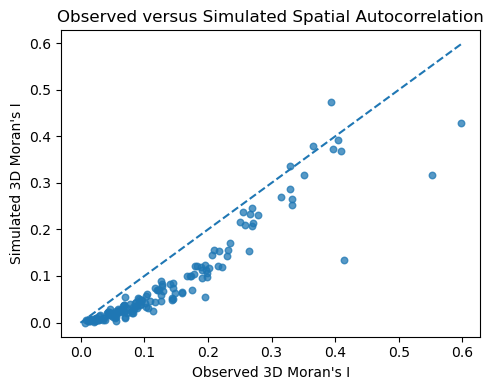

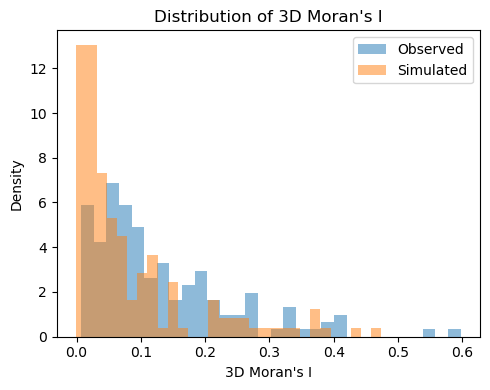

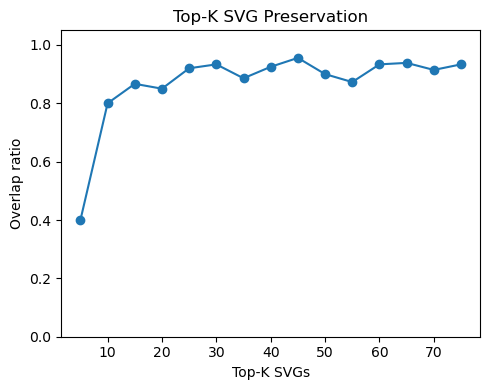

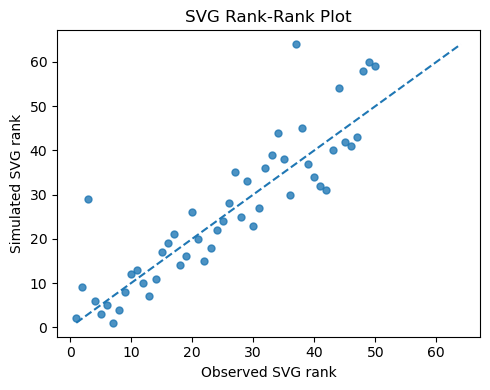

In [9]:
# ============================================================
# Summary evaluation plots
# ============================================================

# Observed versus simulated 3D Moran's I
plt.figure(figsize=(5, 4))
plt.scatter(
    real_I[valid],
    sim_I[valid],
    s=22,
    alpha=0.75
)

lower = float(
    min(real_I[valid].min(), sim_I[valid].min())
)
upper = float(
    max(real_I[valid].max(), sim_I[valid].max())
)

plt.plot(
    [lower, upper],
    [lower, upper],
    linestyle="--"
)
plt.xlabel("Observed 3D Moran's I")
plt.ylabel("Simulated 3D Moran's I")
plt.title("Observed versus Simulated Spatial Autocorrelation")
plt.tight_layout()
plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "moran_observed_vs_simulated.png"
    ),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# Distribution of 3D Moran's I
plt.figure(figsize=(5, 4))
plt.hist(
    real_I[valid],
    bins=30,
    density=True,
    alpha=0.5,
    label="Observed"
)
plt.hist(
    sim_I[valid],
    bins=30,
    density=True,
    alpha=0.5,
    label="Simulated"
)
plt.xlabel("3D Moran's I")
plt.ylabel("Density")
plt.title("Distribution of 3D Moran's I")
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "moran_distribution.png"
    ),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# Top-K SVG overlap
real_order = valid_idx[
    np.argsort(-real_I[valid_idx])
]
sim_order = valid_idx[
    np.argsort(-sim_I[valid_idx])
]

max_k = min(75, len(valid_idx))
K_list = np.arange(5, max_k + 1, 5)
overlap = []

for K in K_list:
    top_real = set(real_order[:K])
    top_sim = set(sim_order[:K])
    overlap.append(
        len(top_real & top_sim) / K
    )

plt.figure(figsize=(5, 4))
plt.plot(K_list, overlap, marker="o")
plt.xlabel("Top-K SVGs")
plt.ylabel("Overlap ratio")
plt.title("Top-K SVG Preservation")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "topk_svg_overlap.png"
    ),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# Rank-rank plot
K_rank = min(50, len(valid_idx))
rank_plot_idx = real_order[:K_rank]

plt.figure(figsize=(5, 4))
max_rank = float(
    max(
        real_rank_full[rank_plot_idx].max(),
        sim_rank_full[rank_plot_idx].max()
    )
)
plt.plot(
    [1, max_rank],
    [1, max_rank],
    linestyle="--",
    zorder=1
)
plt.scatter(
    real_rank_full[rank_plot_idx],
    sim_rank_full[rank_plot_idx],
    s=25,
    alpha=0.8,
    zorder=2
)
plt.xlabel("Observed SVG rank")
plt.ylabel("Simulated SVG rank")
plt.title("SVG Rank-Rank Plot")
plt.tight_layout()
plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "svg_rank_rank.png"
    ),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


Representative genes: ['Mbp', 'Nnat', 'Sln']


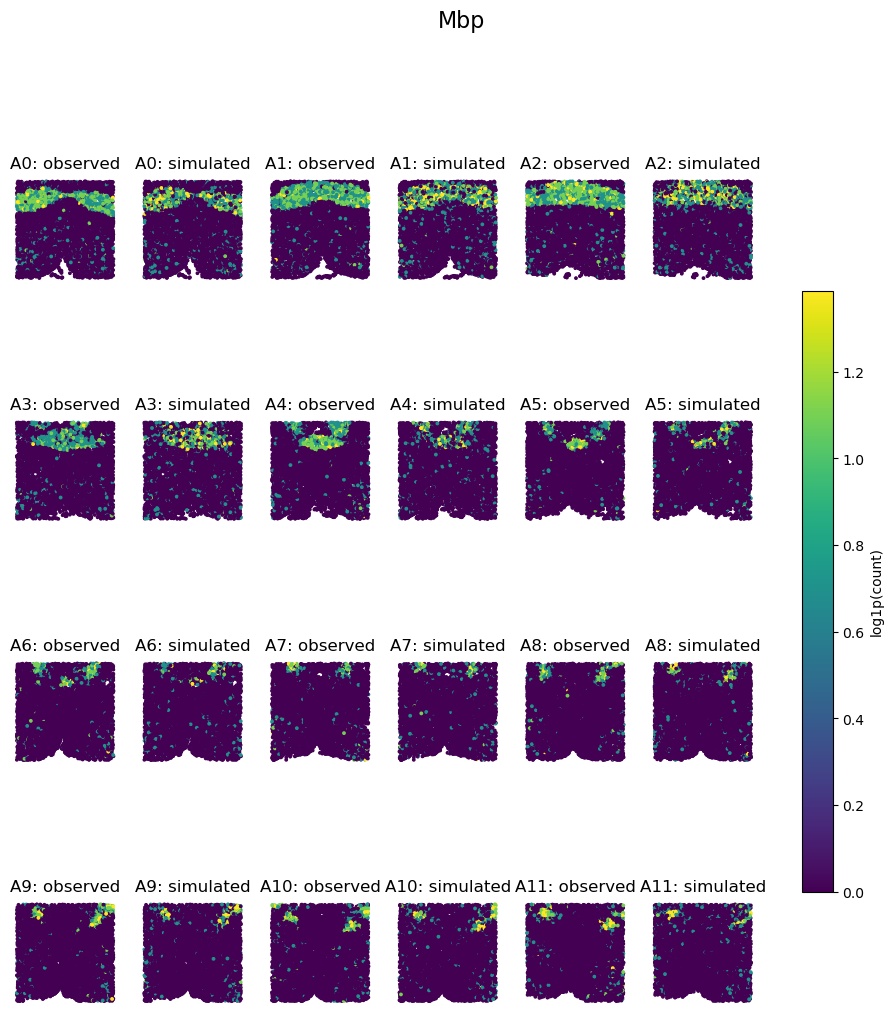

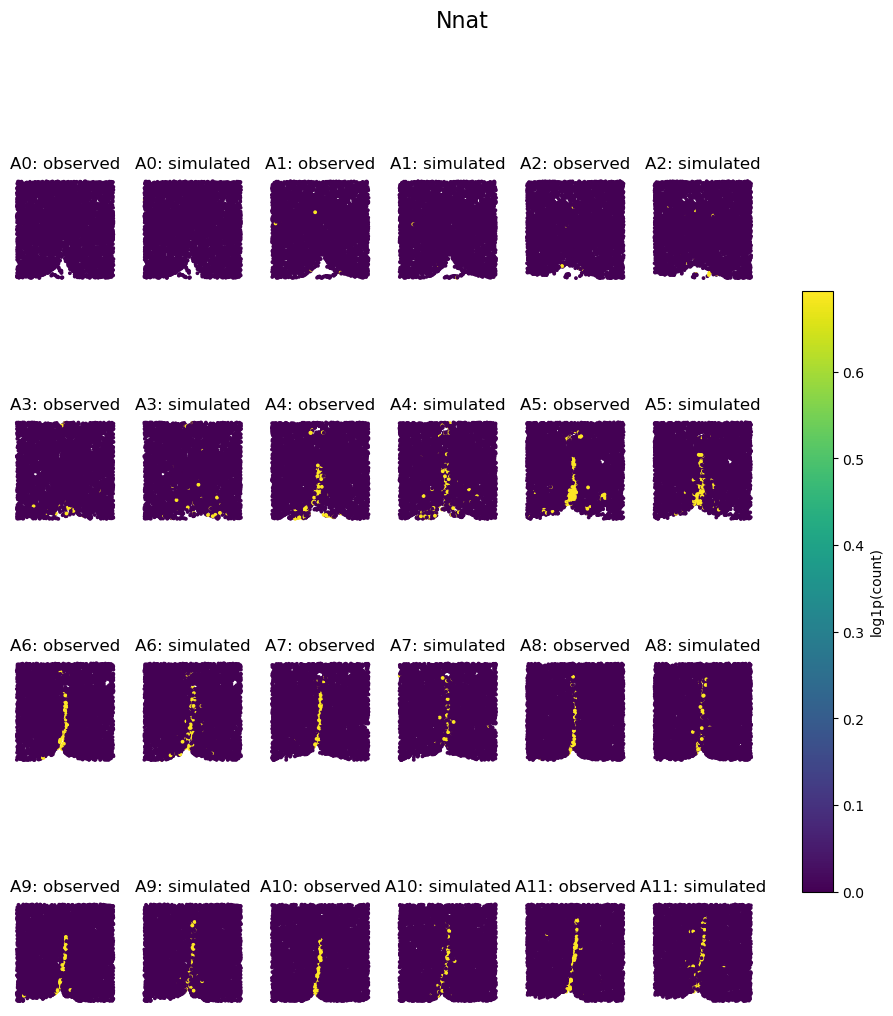

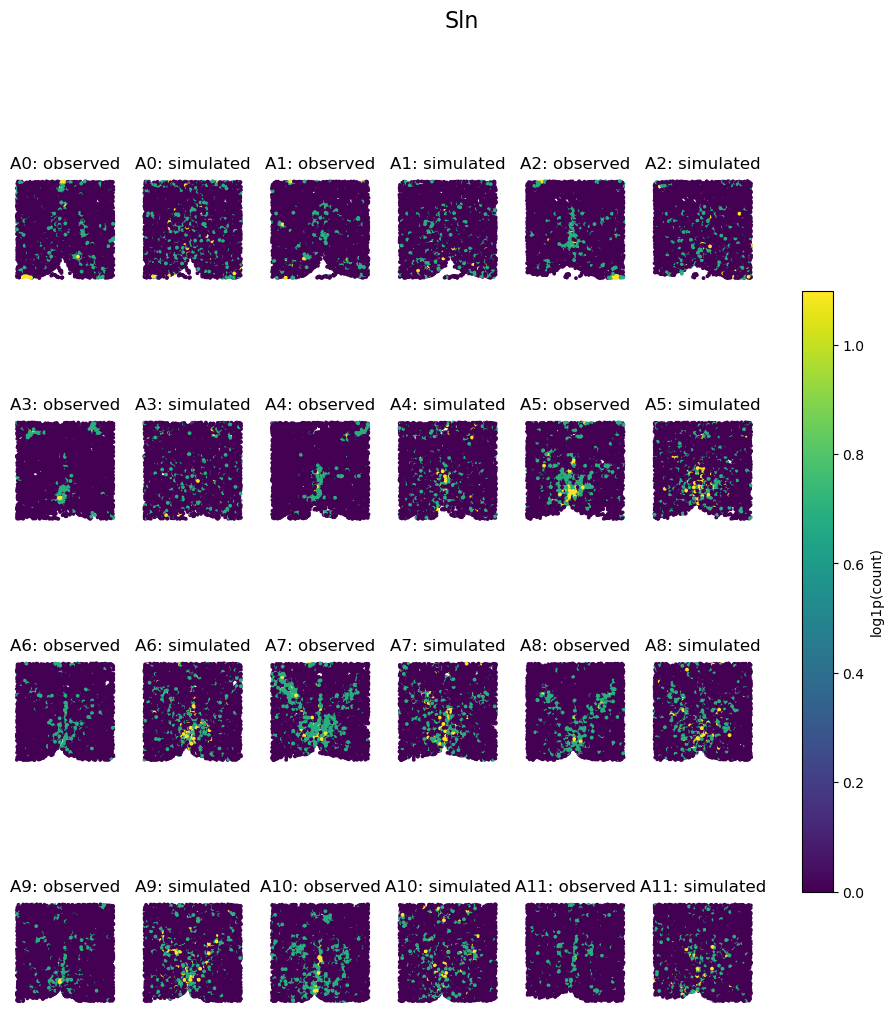

In [10]:
# ============================================================
# Per-slice 2D expression maps for representative genes
# ============================================================

def natural_slice_key(value):
    match = re.search(r"(\d+)$", str(value))
    if match:
        return (0, int(match.group(1)))
    return (1, str(value))


def plot_gene_by_slice(
    gene,
    adata_obj,
    Y_observed,
    Y_simulated,
    gene_names,
    slices_per_row=3,
    point_size=3
):
    gene_index = gene_names.index(gene)

    observed = np.log1p(
        Y_observed[:, gene_index]
    )
    simulated = np.log1p(
        Y_simulated[:, gene_index]
    )

    batch = (
        adata_obj.obs["batch"]
        .astype(str)
        .to_numpy()
    )
    x_all = adata_obj.obs["x"].to_numpy()
    y_all = adata_obj.obs["y"].to_numpy()

    slice_order = sorted(
        np.unique(batch),
        key=natural_slice_key
    )

    n_rows = int(
        np.ceil(len(slice_order) / slices_per_row)
    )
    n_cols = 2 * slices_per_row

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4 * slices_per_row, 3 * n_rows),
        squeeze=False
    )

    vmax = float(
        np.percentile(
            np.concatenate([observed, simulated]),
            99
        )
    )
    if vmax <= 0:
        vmax = 1.0

    scatter_handle = None

    for slice_index, slice_id in enumerate(slice_order):
        row = slice_index // slices_per_row
        pair_position = slice_index % slices_per_row
        col_observed = 2 * pair_position
        col_simulated = col_observed + 1

        mask = batch == slice_id

        scatter_handle = axes[row, col_observed].scatter(
            x_all[mask],
            y_all[mask],
            c=observed[mask],
            s=point_size,
            cmap="viridis",
            vmin=0,
            vmax=vmax
        )
        axes[row, col_observed].set_title(
            f"{slice_id}: observed"
        )

        axes[row, col_simulated].scatter(
            x_all[mask],
            y_all[mask],
            c=simulated[mask],
            s=point_size,
            cmap="viridis",
            vmin=0,
            vmax=vmax
        )
        axes[row, col_simulated].set_title(
            f"{slice_id}: simulated"
        )

        for column in [col_observed, col_simulated]:
            axes[row, column].set_aspect("equal")
            axes[row, column].axis("off")

    for empty_index in range(
        len(slice_order),
        n_rows * slices_per_row
    ):
        row = empty_index // slices_per_row
        pair_position = empty_index % slices_per_row
        axes[row, 2 * pair_position].axis("off")
        axes[row, 2 * pair_position + 1].axis("off")

    fig.suptitle(gene, fontsize=16)

    if scatter_handle is not None:
        fig.colorbar(
            scatter_handle,
            ax=axes.ravel().tolist(),
            shrink=0.65,
            label="log1p(count)"
        )

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            f"{gene}_all_slices_observed_vs_simulated.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()


selected_idx = [
    j for j in real_order
    if (
        np.count_nonzero(Y_true[:, j]) >= 20
        and fit_status.loc[
            fit_status["gene"] == gene_names[j],
            "status"
        ].iloc[0] != "failed"
    )
][:3]

selected_genes = [
    gene_names[j]
    for j in selected_idx
]

print("Representative genes:", selected_genes)

for gene in selected_genes:
    plot_gene_by_slice(
        gene=gene,
        adata_obj=adata_all,
        Y_observed=Y_true,
        Y_simulated=sim_expr,
        gene_names=gene_names,
        slices_per_row=3,
        point_size=3
    )


In [11]:
# ============================================================
# Final failure summary
# ============================================================

failed = fit_status[
    fit_status["status"] == "failed"
].copy()

nonconverged = fit_status[
    fit_status["status"] == "nonconverged"
].copy()

print("Number of successful genes:", int((fit_status["status"] == "success").sum()))
print("Number of nonconverged genes:", len(nonconverged))
print("Number of failed genes:", len(failed))

if not failed.empty:
    print("\nFailed-gene details:")
    print(
        failed[[
            "gene",
            "error",
            "nonzero",
            "variance"
        ]].to_string(index=False)
    )

if not nonconverged.empty:
    print("\nNonconverged-gene details:")
    print(
        nonconverged[[
            "gene",
            "poisson_converged",
            "nb_converged",
            "warnings"
        ]].to_string(index=False)
    )


Number of successful genes: 151
Number of nonconverged genes: 4
Number of failed genes: 0

Nonconverged-gene details:
 gene  poisson_converged  nb_converged warnings
  Cck              False          True         
Gnrh1              False          True         
  Oxt               True         False         
 Ucn3              False          True         
